In [1]:
# ==========================================
# CELL 1: SETUP & MASTER IMPORTS
# ==========================================
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# PyTorch Core
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Vision & Progress Tracking
import torchvision.models as models
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ablation Sandbox Ready. Using device: {device}")

# 1. The Custom .npy Loader
class DeepLenseDataset(Dataset):
    def __init__(self, root_dir):
        self.file_paths = glob.glob(os.path.join(root_dir, '**/*.npy'), recursive=True)
        self.classes = sorted(list(set([os.path.basename(os.path.dirname(p)) for p in self.file_paths])))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        print(f"Dataset Loaded! Found {len(self.file_paths)} total simulations.")
        print(f"Class Mapping: {self.class_to_idx}")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image_array = np.load(img_path, allow_pickle=True) 
        
        if image_array.dtype == object:
            image_array = image_array[0]
            
        image_array = np.array(image_array, dtype=np.float32)
        image_tensor = torch.from_numpy(image_array).float()
         
        if len(image_tensor.shape) == 2:
            image_tensor = image_tensor.unsqueeze(0)
            
        parent_folder = os.path.basename(os.path.dirname(img_path))
        label = self.class_to_idx[parent_folder]
        
        return image_tensor, torch.tensor(label)

# 2. Mount Data & Create DataLoader
dataset_path = '/kaggle/input/datasets/saranga7/gsocml4scimodel2/Model_II' 
lens_dataset = DeepLenseDataset(root_dir=dataset_path)

# For training the baselines, we shuffle. 
train_loader = DataLoader(lens_dataset, batch_size=32, shuffle=True)

Ablation Sandbox Ready. Using device: cuda
Dataset Loaded! Found 89104 total simulations.
Class Mapping: {'axion': 0, 'cdm': 1, 'no_sub': 2}


In [2]:
# ==========================================
# CELL 2: BASELINE ARCHITECTURES
# ==========================================

# 1. Baseline A: ResNet18 (CNN)
def get_resnet_baseline(num_classes=3):
    model = models.resnet18(weights=None)
    # Modify the first convolutional layer to accept 1-channel grayscale images instead of 3-channel RGB
    model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    # Modify the final classification head for our 3 physics classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# 2. Baseline B: Vanilla Vision Transformer (ViT)
class VanillaViT(nn.Module):
    def __init__(self, image_size=64, patch_size=16, in_channels=1, embed_dim=256, num_heads=8, num_classes=3):
        super().__init__()
        self.patch_embed = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (image_size // patch_size) ** 2 
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=512, activation="gelu", batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)
        
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        batch_size = x.shape[0]
        # Create patches
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        # Add CLS token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        # Add positional embedding
        x = x + self.pos_embed
        # Pass through transformer
        x = self.transformer(x)
        # Extract CLS token and classify
        cls_token_out = x[:, 0, :]
        return self.head(cls_token_out)

print("Baseline architectures loaded into memory.")

Baseline architectures loaded into memory.


In [3]:
# ==========================================
# CELL 3: THE MULTI-MODEL TRAINING ENGINE
# ==========================================
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# We match epochs to make it a mathematically fair fight
EPOCHS = 5 


eval_loader = DataLoader(lens_dataset, batch_size=32, shuffle=False)

def train_and_extract(model, model_name, save_file):
    print(f"\n{'='*40}")
    print(f" INITIALIZING {model_name.upper()}")
    print(f"{'='*40}")
    
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    # --- PHASE A: TRAINING ---
    model.train()
    for epoch in range(EPOCHS):
        loop = tqdm(train_loader, desc=f"{model_name} Training [{epoch+1}/{EPOCHS}]")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            
            logits = model(images)
            loss = criterion(logits, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loop.set_postfix(loss=loss.item())
            
    # --- PHASE B: EXTRACTION (Using the unshuffled eval_loader) ---
    print(f"\n Extracting {model_name} Brain Waves...")
    model.eval()
    all_probs = []
    
    with torch.no_grad():
        for images, _ in tqdm(eval_loader, desc=f"{model_name} Evaluation"):
            images = images.to(device)
            logits = model(images)
            probs = F.softmax(logits, dim=1)
            all_probs.extend(probs.cpu().numpy())
            
    # Save the mathematical guesses to disk
    np.save(save_file, np.array(all_probs))
    print(f" {model_name} probabilities saved to '{save_file}'")
    
    # Burn the model out of the GPU RAM to make room for the next one
    del model
    torch.cuda.empty_cache()

# 1. Run the ResNet18 Baseline
resnet_model = get_resnet_baseline(num_classes=3)
train_and_extract(resnet_model, "ResNet-18", "resnet_probs.npy")

# 2. Run the Vanilla ViT Baseline
vit_model = VanillaViT(num_classes=3)
train_and_extract(vit_model, "Vanilla ViT", "vanilla_vit_probs.npy")

print("\n ALL BASELINES COMPLETE! Sandbox is ready for the Master Graph.")


 INITIALIZING RESNET-18


ResNet-18 Training [5/5]: 100%|██████████| 2785/2785 [02:25<00:00, 19.18it/s, loss=0.216]



 Extracting ResNet-18 Brain Waves...


ResNet-18 Evaluation: 100%|██████████| 2785/2785 [01:21<00:00, 34.19it/s]


 ResNet-18 probabilities saved to 'resnet_probs.npy'

 INITIALIZING VANILLA VIT


Vanilla ViT Training [5/5]: 100%|██████████| 2785/2785 [01:58<00:00, 23.50it/s, loss=0.248]



 Extracting Vanilla ViT Brain Waves...


Vanilla ViT Evaluation: 100%|██████████| 2785/2785 [01:32<00:00, 30.22it/s]


 Vanilla ViT probabilities saved to 'vanilla_vit_probs.npy'

 ALL BASELINES COMPLETE! Sandbox is ready for the Master Graph.


Generating the Master 3-Model Comparison Graph...


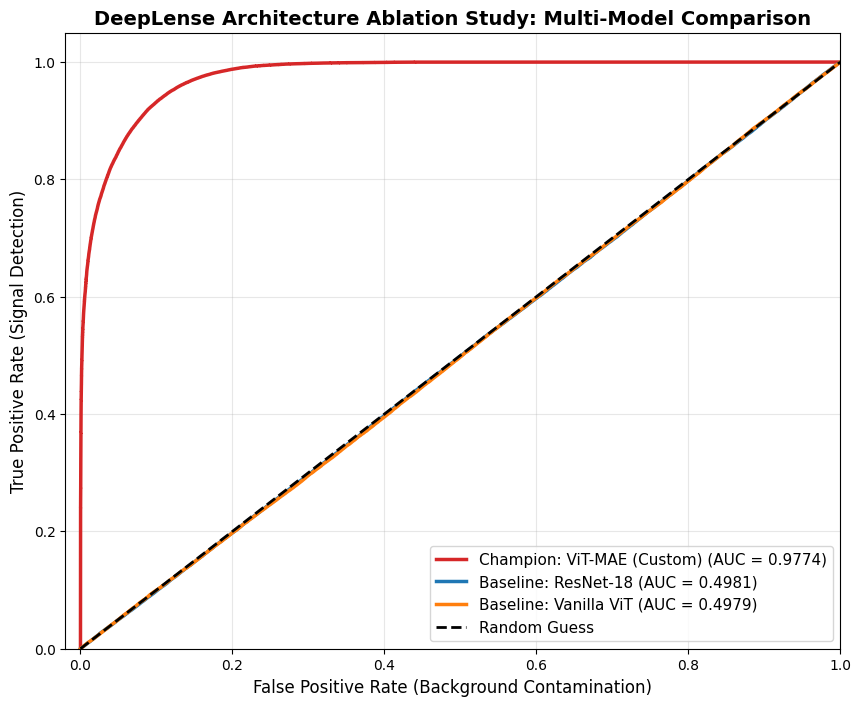

Master Graph successfully generated and saved!


In [4]:
# ==========================================
# CELL 4: THE MASTER ABLATION GRAPH
# ==========================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

print("Generating the Master 3-Model Comparison Graph...")

# --- CRITICAL PATHS ---

PATH_TO_LABELS = '/kaggle/input/models/vanshdistsys2/v-v/pytorch/default/1/ablation_labels.npy' 
PATH_TO_CHAMPION = '/kaggle/input/models/vanshdistsys2/v-v/pytorch/default/1/vit_mae_probs.npy'

# 1. Load the Ground Truth Labels
y_true = np.load(PATH_TO_LABELS)
classes = [0, 1, 2]
y_test_bin = label_binarize(y_true, classes=classes)

# 2. Load the Probabilities from all 3 Models
probs_champion = np.load(PATH_TO_CHAMPION)   
probs_resnet = np.load('resnet_probs.npy')      
probs_vit = np.load('vanilla_vit_probs.npy')     

plt.figure(figsize=(10, 8))

# Function to calculate and plot micro-average ROC
def plot_micro_roc(y_bin, probs, color, label_name):
    fpr, tpr, _ = roc_curve(y_bin.ravel(), probs.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{label_name} (AUC = {roc_auc:.4f})')

# 3. Plot the 3 Competitors on the exact same axes
plot_micro_roc(y_test_bin, probs_champion, color='#d62728', label_name='Champion: ViT-MAE (Custom)')
plot_micro_roc(y_test_bin, probs_resnet, color='#1f77b4', label_name='Baseline: ResNet-18')
plot_micro_roc(y_test_bin, probs_vit, color='#ff7f0e', label_name='Baseline: Vanilla ViT')

# 4. Formatting the Graph for Publication
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Contamination)', fontsize=12)
plt.ylabel('True Positive Rate (Signal Detection)', fontsize=12)
plt.title('DeepLense Architecture Ablation Study: Multi-Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

# Save the final masterpiece to your output folder
plt.savefig('DeepLense_Master_Ablation_Graph.png', dpi=300, bbox_inches='tight')
plt.show()
print("Master Graph successfully generated and saved!")